# Atelier Préparation de Données Textuelles

**Contexte**


Une entreprise souhaite développer un système capable de classer automatiquement des avis
clients afin d'identifier leur sentiment.
Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction,
réseaux sociaux et service client.
Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe,
majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères,
textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes.
Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent
donc construire un pipeline complet de préparation des données textuelles.

**Objectifs pédagogiques**

À la fin de l'atelier, l'apprenant doit être capable de :
1) explorer un corpus textuel ;
2) identifier les problèmes de qualité des données ;
3) nettoyer les textes ;
4) tokeniser les textes ;
5) normaliser les données textuelles ;
6) transformer les textes en représentations numériques ;
7) comparer plusieurs méthodes de vectorisation ;
8) préparer un corpus exploitable par un modèle de ML/DL.

**Structure du projet :**
```
atelier_prepa_donnees_textuelles/
│
├── notebooks/
│   └── atelier_prepa_donnees_textuelles.ipynb
│
└── data/
    ├── smart_reviews_raw.csv        <- données brutes fournies
    ├── smart_reviews_cleaned.csv    <- créé après la Partie 4 (normalisation)
    └── tfidf_matrix.npz             <- créé après la Partie 6 (vectorisation)
```

**Imports des bibliothéques et configuration**

In [42]:
#  pandas / numpy : Pour la manipulation de données tabulaires et calcul numérique
import pandas as pd
import numpy as np

# re : Pour le module Python natif d'expressions régulières (regex), notre outil principal
#     pour repérer et supprimer URLs, mentions, hashtags, ponctuation, etc.
import re

#  matplotlib / seaborn : Pour la visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#  collections.Counter : pour compter facilement des occurrences (mots, tokens...)
from collections import Counter

#  pathlib : Pour la gestion des chemins de fichiers
from pathlib import Path

#  scikit-learn : Pour le découpage train/test et vectorisation (Bag of Words, TF-IDF)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

#  scipy.sparse : pour sauvegarder/charger une matrice creuse (sparse) comme celle produite
#     par la vectorisation de texte (voir Partie 6)
import scipy.sparse as sp

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 42

DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "smart_reviews_raw.csv"
CLEANED_PATH = DATA_DIR / "smart_reviews_cleaned.csv"
MATRIX_PATH = DATA_DIR / "tfidf_matrix.npz"

print("Configuration prête.")

Configuration prête.


**Partie 1 – Exploration du corpus**

1) Charger les données CSV 

In [43]:
df = pd.read_csv("../data/smart_reviews_raw.csv")

df.head(3)

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr


2) Combien d'avis contient le dataset 

In [44]:
n_avis = df.shape[0]
print(f"Le dataset contient {n_avis} avis.")

Le dataset contient 1200 avis.


3) Combien de colonnes possède-t-il ?

In [45]:
nb_cols = df.shape[1]
print(f"Le dataset contient {nb_cols} colonnes.")

df.columns.tolist()

Le dataset contient 8 colonnes.


['id_avis',
 'date',
 'source',
 'produit',
 'texte',
 'sentiment',
 'note',
 'langue']

4) Quel est le type de chaque colonne ?

In [46]:
df.dtypes

id_avis      object
date         object
source       object
produit      object
texte        object
sentiment    object
note          int64
langue       object
dtype: object

5) Existe-t-il des valeurs manquantes ?

In [47]:
valeurs_manquantes = df.isna().sum()
pourcentage_manquant = (df.isna().mean() * 100).round(2)

pd.DataFrame({
    "nb_manquants": valeurs_manquantes,
    "pct_manquants": pourcentage_manquant,
})

,nb_manquants,pct_manquants
id_avis,0,0.00
date,0,0.00
source,0,0.00
produit,0,0.00
texte,5,0.42
sentiment,0,0.00
note,0,0.00
langue,0,0.00


**Interprétation :** seule la colonne `texte` contient des valeurs manquantes. C'est LA colonne
la plus critique de tout l'atelier (c'est elle qu'on va nettoyer, tokeniser, vectoriser...) : ces
lignes sans texte seront supprimées dès le début de la Partie 2, puisqu'un modèle de classification
de sentiment ne peut rien faire d'un avis vide.

6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte
contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte
contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec
répétition de caractères.

In [48]:
def afficher_exemple(masque, titre, colonne="texte"):
    """Affiche le premier exemple de df correspondant au masque booléen donné."""
    sous_ensemble = df[masque]
    print(f"--- {titre} ({len(sous_ensemble)} avis trouvés) ---")
    if len(sous_ensemble) > 0:
        print(repr(sous_ensemble[colonne].iloc[0]))
    else:
        print("(aucun exemple trouvé)")
    print()


texte = df["texte"]

# texte normal : un texte "propre" sans caractère spécial
afficher_exemple(texte.notna() & ~texte.str.contains(r'http|@|#|[👍😊😢😡]', na=False, regex=True),
                  "Texte normal")

# texte vide : valeur manquante (NaN) OU chaîne vide/espaces uniquement
afficher_exemple(texte.isna() | (texte.fillna("").str.strip() == ""), "Texte vide")

# texte contenant une URL
afficher_exemple(texte.str.contains(r'https?://', na=False, regex=True), "Texte avec URL")

# texte contenant une mention (@pseudo)
afficher_exemple(texte.str.contains(r'@\w+', na=False, regex=True), "Texte avec mention")

# texte contenant un hashtag (#mot)
afficher_exemple(texte.str.contains(r'#\w+', na=False, regex=True), "Texte avec hashtag")

# texte contenant des emojis (on cible ici les plages Unicode des emojis les plus courants)
afficher_exemple(texte.str.contains(r'[\U0001F300-\U0001FAFF\U00002600-\U000027BF]', na=False, regex=True),
                  "Texte avec emoji")

# texte avec beaucoup de ponctuation (3 signes de ponctuation identiques ou plus à la suite)
afficher_exemple(texte.str.contains(r'([!?.]){2,}', na=False, regex=True), "Texte avec ponctuation répétée")

# texte en majuscules (au moins un mot de 3 lettres ou plus tout en majuscules)
afficher_exemple(texte.str.contains(r'\b[A-ZÀ-Ü]{3,}\b', na=False, regex=True), "Texte en majuscules")

# texte avec répétition de caractères (ex: "trèèès", "supeeer")
afficher_exemple(texte.str.contains(r'(\w)\1{2,}', na=False, regex=True), "Texte avec répétition de caractères")

--- Texte normal (627 avis trouvés) ---
'Très  bonne  expérience,  simple  et  efficace.'

--- Texte vide (6 avis trouvés) ---
nan

--- Texte avec URL (143 avis trouvés) ---
'Produit parfait, rien à signaler. https://example.com/commande/17'

--- Texte avec mention (128 avis trouvés) ---
'@client Livraison rapide et produit conforme à mes attentes.'

--- Texte avec hashtag (127 avis trouvés) ---
'Très satisfait de mon achat 👍 #avis'

--- Texte avec emoji (192 avis trouvés) ---
'Très satisfait de mon achat 👍 #avis'

--- Texte avec ponctuation répétée (141 avis trouvés) ---
'Produit excellent, je suis très satisfait. !!!'

--- Texte en majuscules (144 avis trouvés) ---
"LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."

--- Texte avec répétition de caractères (22 avis trouvés) ---
'Produit excellent, je suis trèèès satisfait.'



C:\Users\HP\AppData\Local\Temp\ipykernel_7148\262054705.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  afficher_exemple(texte.str.contains(r'([!?.]){2,}', na=False, regex=True), "Texte avec ponctuation répétée")
C:\Users\HP\AppData\Local\Temp\ipykernel_7148\262054705.py:41: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  afficher_exemple(texte.str.contains(r'(\w)\1{2,}', na=False, regex=True), "Texte avec répétition de caractères")


7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer :
longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

On crée une colonne `longueur` (nombre de caractères) pour chaque avis, en traitant les valeurs
manquantes comme des textes de longueur 0.

In [49]:
df["longueur"] = df["texte"].fillna("").str.len()

statistiques_longueur = df["longueur"].describe()
print(statistiques_longueur)
print()
print("Médiane :", df["longueur"].median())
print()
print("Quartiles :")
print(df["longueur"].quantile([0.25, 0.5, 0.75]))

count    1200.000000
mean       48.963333
std        22.350913
min         0.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64

Médiane : 48.0

Quartiles :
0.25    37.0
0.50    48.0
0.75    56.0
Name: longueur, dtype: float64


8) Visualiser la distribution de la longueur des avis puis répondre aux questions

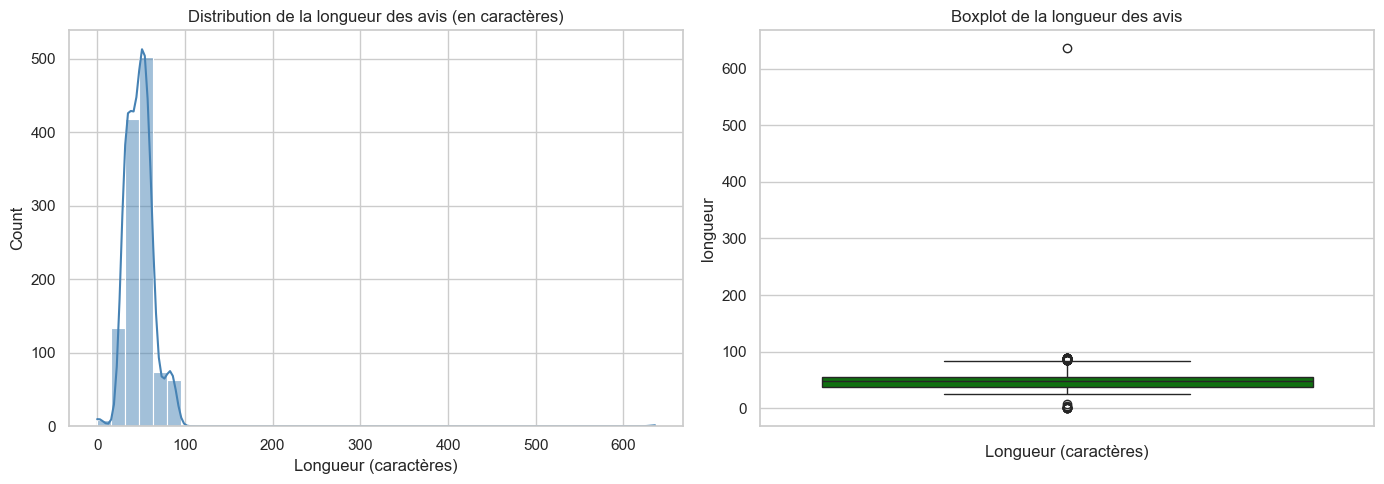

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["longueur"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution de la longueur des avis (en caractères)")
axes[0].set_xlabel("Longueur (caractères)")

sns.boxplot(y=df["longueur"], ax=axes[1], color="green")
axes[1].set_title("Boxplot de la longueur des avis")
axes[1].set_xlabel("Longueur (caractères)")

plt.tight_layout()
plt.show()

a) Existe-t-il des textes anormalement longs ?

Aprés observation On repère un avis anormalement long qui peut étre due a une  **répétition de la même phrase en boucle** ("Le produit est bien, mais la livraison a été longue.")
— probablement un bug de collecte côté source, plutôt qu'un vrai avis détaillé. On traitera ce
type de cas dans le Bonus (Partie 7), avec une détection de "spam par répétition".

Pour une meilleur compréhension nous allons écrire un code qui vas nous permettre de confirmer notre observation

In [51]:
seuil_long = df["longueur"].quantile(0.99)
textes_longs = df[df["longueur"] > seuil_long]
print(f"Seuil du 99e percentile : {seuil_long:.0f} caractères")
print(f"Nombre de textes au-delà de ce seuil : {len(textes_longs)}")
print()
for t in textes_longs["texte"]:
    print(repr(t[:300]))

Seuil du 99e percentile : 87 caractères
Nombre de textes au-delà de ce seuil : 11

"La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/111"
"La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/319"
"La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/408"
"La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/602"
'Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livrai'
"La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/686"
"La batterie tient vraiment bien et l'écran est superbe. https://example.com/commande/910"
"La batterie tient vraiment bien et l'écran est superbe. https://exa

b) Existe-t-il beaucoup de textes très courts ?

Aprés observation on trouve quelques textes très courts mais parfaitement légitimes
contrairement au texte anormalement long, ce ne sont pas des erreurs — un avis
très court est une situation tout à fait normale et fréquente certains jeux de données. On ne
les supprimera donc pas, à la différence des textes réellement vides.

In [52]:
seuil_court = 10 # c a fixé par soit méme 
textes_courts = df[(df["longueur"] > 0) & (df["longueur"] < seuil_court)]
print(f"Nombre de textes non vides mais très courts (< {seuil_court} caractères) : {len(textes_courts)}")
textes_courts[["id_avis", "texte", "longueur", "sentiment"]]

Nombre de textes non vides mais très courts (< 10 caractères) : 4


,id_avis,texte,longueur,sentiment
224,AV0225,OK,2,positif
554,AV0555,Pas bon,7,neutre
889,AV0890,OK,2,positif
951,AV0952,,3,positif


9) Détecter les textes vides

In [53]:
masque_texte_vide = df["texte"].isna() | (df["texte"].fillna("").str.strip() == "")
textes_vides = df[masque_texte_vide]

print(f"Nombre total de textes vides (NaN ou chaîne vide/espaces) : {len(textes_vides)}")
print(f"  dont valeurs manquantes (NaN)         : {df['texte'].isna().sum()}")
print(f"  dont chaîne vide/espaces (non-NaN)    : {(masque_texte_vide & df['texte'].notna()).sum()}")
textes_vides[["id_avis", "texte"]]

Nombre total de textes vides (NaN ou chaîne vide/espaces) : 6
  dont valeurs manquantes (NaN)         : 5
  dont chaîne vide/espaces (non-NaN)    : 1


,id_avis,texte
46,AV0047,NaN
108,AV0109,NaN
310,AV0311,NaN
640,AV0641,NaN
781,AV0782,NaN
951,AV0952,


10) Détecter les doublons sur le texte

In [54]:
doublons_texte = df[df["texte"].notna() & df["texte"].duplicated(keep=False)]
doublons_texte = doublons_texte.sort_values("texte")

print(f"Nombre de lignes impliquées dans un doublon de texte : {len(doublons_texte)}")
print(f"Nombre de valeurs de texte uniques concernées : {df['texte'].dropna()[df['texte'].dropna().duplicated(keep=False)].nunique()}")
print()
doublons_texte[["id_avis", "texte", "sentiment"]].head(15)

Nombre de lignes impliquées dans un doublon de texte : 1031
Nombre de valeurs de texte uniques concernées : 154



,id_avis,texte,sentiment
312,AV0313,@client Excellent rapport qualité-prix.,positif
419,AV0420,@client Excellent rapport qualité-prix.,positif
1099,AV1100,@client Excellent rapport qualité-prix.,positif
45,AV0046,@client Excellent rapport qualité-prix.,positif
466,AV0467,@client Excellent rapport qualité-prix.,positif
1059,AV1060,@client Excellent rapport qualité-prix.,positif
146,AV0147,@client Excellent rapport qualité-prix.,positif
593,AV0594,@client Excellent rapport qualité-prix.,positif
611,AV0612,@client Excellent rapport qualité-prix.,positif
398,AV0399,@client Excellent rapport qualité-prix.,positif


**Interprétation :** c'est un chiffre très élevé — la majorité des avis du dataset sont en
réalité des **doublons ou quasi-doublons** d'un petit nombre de phrases "modèles" (probablement des
avis synthétiques générés à partir de templates). On les traitera en Partie 2.

11) Les classes sont-elles équilibrées ?

In [55]:
repartition_sentiment = df["sentiment"].value_counts()
repartition_pct = df["sentiment"].value_counts(normalize=True) * 100

pd.DataFrame({"nombre": repartition_sentiment, "pourcentage": repartition_pct.round(1)})

,nombre,pourcentage
sentiment,,
positif,776,64.7
neutre,246,20.5
negatif,178,14.8


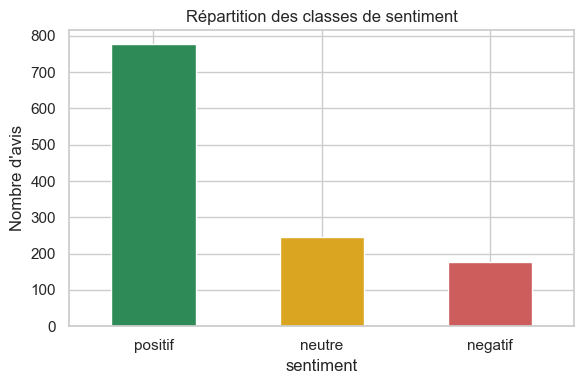

Ratio classe majoritaire / classe minoritaire : 4.36


In [56]:
plt.figure(figsize=(6, 4))
repartition_sentiment.plot(kind="bar", color=["seagreen", "goldenrod", "indianred"])
plt.title("Répartition des classes de sentiment")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ratio_desequilibre = repartition_sentiment.max() / repartition_sentiment.min()
print(f"Ratio classe majoritaire / classe minoritaire : {ratio_desequilibre:.2f}")

12) Quelle est la classe majoritaire ?

Aprés visualisation de la répartition des classes nous pouvons conclure que la classe majoritaire est la classe positive

Pour une confirmation nous allons récuperer l'index de la classe majoritaire via un petit code 

In [57]:
classe_majoritaire = df["sentiment"].value_counts().idxmax()
print(f"La classe majoritaire est : '{classe_majoritaire}'")

La classe majoritaire est : 'positif'


13) Quelles métriques de classification à envisager d’utiliser ?

Avec un tel déséquilibre de classes, **l'accuracy (taux de bonnes réponses) seule est trompeuse** :
un modèle qui prédirait bêtement `positif` pour tous les avis obtiendrait déjà une accuracy proche
de 65 % sans avoir rien appris ! Il faut donc privilégier des métriques qui tiennent compte de
chaque classe individuellement :

- **Le F1-score macro** : la moyenne du F1-score de chaque classe, chaque classe comptant pour un
  poids égal — ça empêche la classe majoritaire de "masquer" une mauvaise performance sur les
  classes minoritaires (`negatif`, `neutre`).
- **La precision et le recall par classe** : utile pour savoir, par exemple, si le modèle confond
  souvent `neutre` avec `positif`.
- **La matrice de confusion** : pour visualiser précisément quelles classes sont confondues entre
  elles.
- **Le F1-score pondéré (weighted)** si on veut malgré tout refléter l'importance réelle de chaque
  classe dans les données (utile pour un rapport business), en complément — mais jamais seul.

**À éviter comme métrique principale ici : l'accuracy brute**, car elle survalorise la performance
sur la classe majoritaire `positif`.

14) Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères
spéciaux ; ponctuation répétée ; …

On combine ici, sur l'ensemble du dataset, tous les indicateurs de caractères particuliers vus à
la question 6, pour avoir une vue d'ensemble chiffrée.

In [58]:
indicateurs_caracteres = pd.DataFrame({
    "URL": texte.str.contains(r'https?://', na=False, regex=True),
    "Mention (@)": texte.str.contains(r'@\w+', na=False, regex=True),
    "Hashtag (#)": texte.str.contains(r'#\w+', na=False, regex=True),
    "Emoji": texte.str.contains(r'[\U0001F300-\U0001FAFF\U00002600-\U000027BF]', na=False, regex=True),
    "Chiffres": texte.str.contains(r'\d', na=False, regex=True),
    "Ponctuation répétée": texte.str.contains(r'([!?.]){2,}', na=False, regex=True),
    "Caractère répété (mot)": texte.str.contains(r'(\w)\1{2,}', na=False, regex=True),
    "Tout en MAJUSCULES (un mot)": texte.str.contains(r'\b[A-ZÀ-Ü]{3,}\b', na=False, regex=True),
})

resume_caracteres = indicateurs_caracteres.sum().sort_values(ascending=False)
resume_caracteres = resume_caracteres.rename("nombre_avis_concernes")
resume_caracteres

C:\Users\HP\AppData\Local\Temp\ipykernel_7148\3283194698.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "Ponctuation répétée": texte.str.contains(r'([!?.]){2,}', na=False, regex=True),
C:\Users\HP\AppData\Local\Temp\ipykernel_7148\3283194698.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "Caractère répété (mot)": texte.str.contains(r'(\w)\1{2,}', na=False, regex=True),


Emoji                          192
Tout en MAJUSCULES (un mot)    144
URL                            143
Chiffres                       142
Ponctuation répétée            141
Mention (@)                    128
Hashtag (#)                    127
Caractère répété (mot)          22
Name: nombre_avis_concernes, dtype: int64

La représentation par une graphe

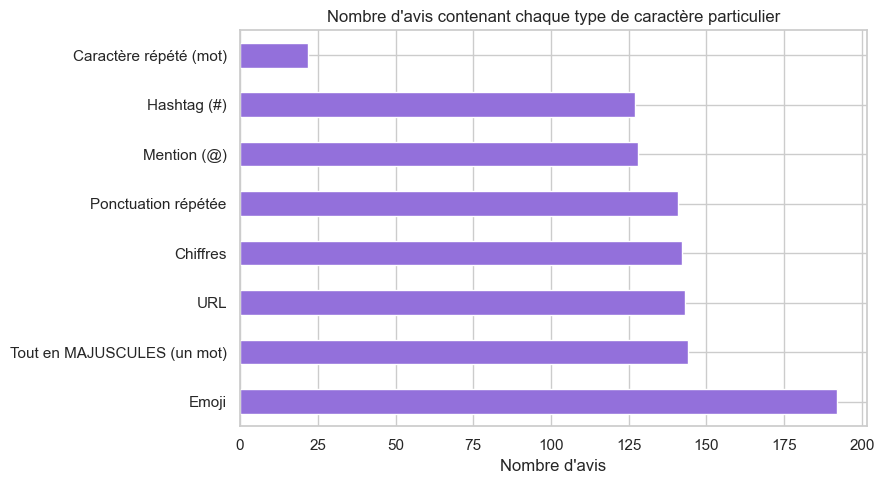

In [59]:
plt.figure(figsize=(9, 5))
resume_caracteres.plot(kind="barh", color="mediumpurple")
plt.title("Nombre d'avis contenant chaque type de caractère particulier")
plt.xlabel("Nombre d'avis")
plt.tight_layout()
plt.show()

15) Visualiser et commenter nombre d'avis par source

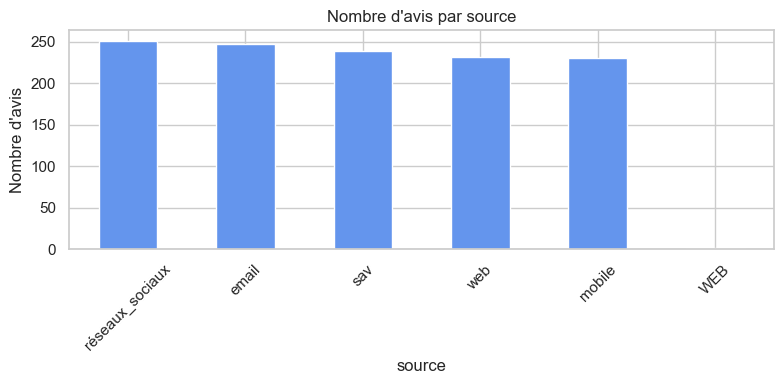

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64

In [60]:
plt.figure(figsize=(8, 4))
df["source"].value_counts().plot(kind="bar", color="cornflowerblue")
plt.title("Nombre d'avis par source")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df["source"].value_counts()

**Commentaire :** les avis sont globalement bien répartis entre les 5 sources attendues
(`web`, `mobile`, `sav`, `email`, `réseaux_sociaux`) — mais on remarque une catégorie `WEB` en
majuscules, clairement une **incohérence de casse** avec `web` : ce sont en réalité la même source,
mal uniformisée à la collecte. C'est exactement le type de problème de qualité mentionné dans le
contexte de notre l'atelier, même si l'énoncé le pointe surtout pour la colonne
`texte` — ici on le voit aussi sur une colonne catégorielle. On la corrigera en Partie 2.

16) Visualiser et commenter le nombre d'avis par produit

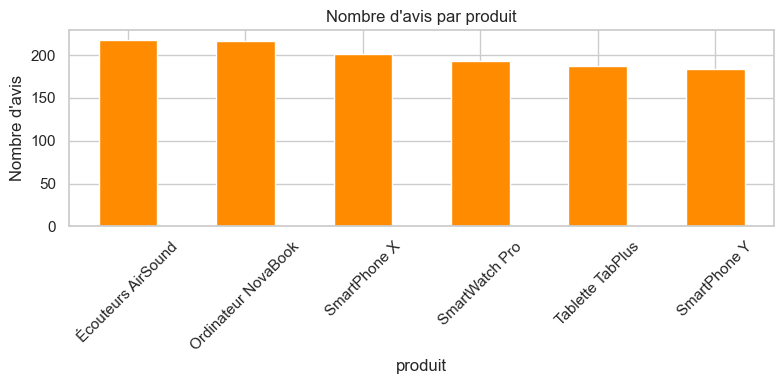

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64

In [61]:
plt.figure(figsize=(8, 4))
df["produit"].value_counts().plot(kind="bar", color="darkorange")
plt.title("Nombre d'avis par produit")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df["produit"].value_counts()

**Commentaire :** les 6 produits du catalogue sont représentés de façon relativement homogène
(entre ~184 et ~218 avis chacun), sans déséquilibre marquant comme on l'a observé pour la variable
`sentiment`. Cette variable ne sera pas utilisée comme cible du modèle (c'est `sentiment` qui joue
ce rôle), mais elle pourrait servir de variable de segmentation dans une analyse plus poussée
(ex. : "quel produit reçoit le plus d'avis négatifs ?").

**Partie 2 – Nettoyage**

1) Supprimer les lignes contenant des valeurs manquantes de texte

Nous allons maintenant nettoyer le corpus étape par étape. **j'ai choisi de travailler sur une copie** (`df_clean`)
pour toujours garder `df` intact (les données brutes), au cas où on aurait besoin d'y revenir.

In [62]:
df_clean = df.copy()
print(f"Nombre de lignes au départ : {len(df_clean)}")

Nombre de lignes au départ : 1200


Comme  nous l'avons vu en Partie 1 (la question 5 et 9) : certaines lignes n'ont pas de texte du tout (`NaN`). Sans
texte, il n'y a tout simplement rien à classifier — ces lignes n'apportent aucune information
utilisable, donc on les retire.

In [63]:
avant = len(df_clean)
df_clean = df_clean.dropna(subset=["texte"]).copy()
apres = len(df_clean)
print(f"Lignes supprimées (texte manquant) : {avant - apres}")
print(f"Lignes restantes : {apres}")

Lignes supprimées (texte manquant) : 5
Lignes restantes : 1195


Je vais en profiter pour aussi retirer les textes qui ne sont **pas** `NaN` mais qui sont
vides une fois débarrassés de leurs espaces (comme on l'avait traiter à la question 9).

In [64]:
avant = len(df_clean)
df_clean = df_clean[df_clean["texte"].str.strip() != ""].copy()
apres = len(df_clean)
print(f"Lignes supprimées (texte vide/espaces) : {avant - apres}")
print(f"Lignes restantes : {apres}")

Lignes supprimées (texte vide/espaces) : 1
Lignes restantes : 1194


2) Supprimer les doublons

On supprime les lignes dont le texte est **exactement identique** à une ligne précédente, en ne
gardant que la première occurrence (`keep="first"`).

In [65]:
avant = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["texte"], keep="first").copy()
apres = len(df_clean)
print(f"Doublons supprimés : {avant - apres}")
print(f"Lignes restantes : {apres}")

Doublons supprimés : 877
Lignes restantes : 317


3) Supprimer les URLs

Une URL (`https://example.com/commande/1024`) n'apporte **aucune information sur le sentiment** de
l'avis — c'est du bruit pur pour notre tâche de classification. On la supprime avec une expression
régulière (regex).

**Comment lire cette regex : `https?://\S+`**
- `https?` → le caractère `s` est optionnel (`?`), donc ça capture aussi bien `http://` que `https://`
- `://` → les caractères littéraux qui suivent toujours le protocole
- `\S+` → une ou plusieurs (`+`) occurrences de n'importe quel caractère qui n'est **pas** un espace
  (`\S` = "non-space"), c'est-à-dire tout le reste de l'URL jusqu'au prochain espace

In [66]:
def supprimer_urls(texte):
    return re.sub(r'https?://\S+|www\.\S+', ' ', texte)


exemple_url = df_clean[df_clean["texte"].str.contains("http", na=False)]["texte"].iloc[0]
print("Avant :", repr(exemple_url))
print("Après :", repr(supprimer_urls(exemple_url)))

Avant : 'Produit parfait, rien à signaler. https://example.com/commande/17'
Après : 'Produit parfait, rien à signaler.  '


4) Traiter les mentions et hashtags avec la stratégie la plus pertinente pour une classification de
sentiment

Nous avons vu en Partie 1 que le corpus contient deux motifs :
- des **mentions** (`@client`, `@support`) : ce sont juste des noms d'utilisateurs interpellés,
  elles ne portent **aucune information de sentiment**.
- des **hashtags** (`#avis`, `#déception`) : ici, la plupart sont génériques (`#avis`, sans valeur
  ajoutée), mais on trouve aussi `#déception` — un mot qui porte au contraire un **vrai signal de
  sentiment négatif** !

**La stratégie retenue :**
- **Mentions → supprimées entièrement**, elles n'ont aucune valeur pour notre tâche.
- **Hashtags → on retire seulement le symbole `#`, en gardant le mot.** Ainsi, `#déception` devient
  simplement `déception`, un mot que le modèle pourra ensuite apprendre à associer au sentiment
  négatif, comme n'importe quel autre mot du texte.

In [67]:
def traiter_mentions_hashtags(texte):
    # Mentions : @pseudo -> supprimé entièrement
    texte = re.sub(r'@\w+', ' ', texte)
    # Hashtags : #mot -> on garde seulement "mot" (groupe capturé entre parenthèses)
    texte = re.sub(r'#(\w+)', r'\1', texte)
    return texte


exemples = df_clean[df_clean["texte"].str.contains(r"[@#]", na=False, regex=True)]["texte"].head(3)
for ex in exemples:
    print("Avant :", repr(ex))
    print("Après :", repr(traiter_mentions_hashtags(ex)))
    print()

Avant : 'Très satisfait de mon achat 👍 #avis'
Après : 'Très satisfait de mon achat 👍 avis'

Avant : '@client Livraison rapide et produit conforme à mes attentes.'
Après : '  Livraison rapide et produit conforme à mes attentes.'

Avant : "La batterie tient vraiment bien et l'écran est superbe. #avis"
Après : "La batterie tient vraiment bien et l'écran est superbe. avis"



5) Nettoyer les espaces

J'ai remarqué qu'a la premiére partie (question 6, "texte normal") que certains avis contiennent des
**espaces multiples** ("Très  bonne  expérience,  simple..."), probablement dus à un bug de
formatage lors de la collecte. La regex `\s+` capture une ou plusieurs espaces consécutifs
(y compris tabulations, retours à la ligne...) et on les remplace par **un seul** espace, puis on
retire les espaces en début/fin de chaîne avec `.strip()`.

In [68]:
def nettoyer_espaces(texte):
    texte = re.sub(r'\s+', ' ', texte)
    return texte.strip()


exemple_espaces = "Très  bonne  expérience,  simple  et  efficace."
print("Avant :", repr(exemple_espaces))
print("Après :", repr(nettoyer_espaces(exemple_espaces)))

Avant : 'Très  bonne  expérience,  simple  et  efficace.'
Après : 'Très bonne expérience, simple et efficace.'


6) Traiter la ponctuation avec la stratégie la plus pertinente pour une classification de sentiment

**Le dilemme :** la ponctuation comme `!!!` ou `???` porte une vraie **information d'intensité
émotionnelle** ("Génial !!!" est plus enthousiaste que "Génial."). Mais pour du Bag of Words / TF-IDF
classiques (Partie 6), qui comptent des **mots**, la ponctuation est de toute façon ignorée par le
tokenizer et n'apporterait rien à ce type de représentation.

**Stratégie retenue :**
- On **supprime la ponctuation** du texte utilisé pour la vectorisation classique (BoW/TF-IDF), car
  elle ne sera de toute façon pas exploitée par ces méthodes.
- **Mais on ne perd pas complètement cette information !** On la capture séparément, **avant** de
  la supprimer, sous forme d'une variable numérique dédiée (ex. `nb_exclamations`) qu'on pourra
  réutiliser comme feature additionnelle si besoin — cette idée sera implémenté en Bonus (Partie 7).

On profite de cette étape pour aussi réduire les **répétitions de caractères** (mentionnées dans le
contexte de l'atelier) comme `"trèèès"` ou `"supeeer"` : on les ramène à un maximum de 2 lettres
identiques consécutives (`"trèèès"` → `"trèès"`), ce qui neutralise l'exagération tout en
préservant les vrais doubles consonnes du français (`"belle"`, `"intéressant"`...).

In [69]:
def reduire_repetitions(texte):
    return re.sub(r'(.)\1{2,}', r'\1\1', texte)


def traiter_ponctuation(texte):
    return re.sub(r'[^\w\sÀ-ÖØ-öø-ÿ]', ' ', texte, flags=re.UNICODE)


exemple_repetition = "Produit excellent, je suis trèèès satisfait. !!!"
apres_repetition = reduire_repetitions(exemple_repetition)
apres_ponctuation = traiter_ponctuation(apres_repetition)

print("Original             :", repr(exemple_repetition))
print("Après réduction       :", repr(apres_repetition))
print("Après ponctuation     :", repr(apres_ponctuation))

Original             : 'Produit excellent, je suis trèèès satisfait. !!!'
Après réduction       : 'Produit excellent, je suis trèès satisfait. !!'
Après ponctuation     : 'Produit excellent  je suis trèès satisfait    '


7) Créer une fonction de nettoyage pour automatiser les actions ci-dessus

On assemble maintenant toutes les étapes (3 à 6) dans **une seule fonction**, appliquée dans le bon
ordre. L'ordre compte : par exemple, on traite les hashtags **avant** de supprimer la ponctuation
(sinon le `#` serait déjà parti et on ne saurait plus distinguer un hashtag d'un mot normal).

In [70]:
def nettoyer_texte(texte):
    """
    Pipeline complet de nettoyage d'un avis client, dans l'ordre :
      1) suppression des URLs
      2) suppression des mentions / conversion des hashtags en mots simples
      3) réduction des répétitions de caractères (trèèès -> trèès)
      4) suppression de la ponctuation et des emojis
      5) nettoyage des espaces multiples
    """
    texte = supprimer_urls(texte)
    texte = traiter_mentions_hashtags(texte)
    texte = reduire_repetitions(texte)
    texte = traiter_ponctuation(texte)
    texte = nettoyer_espaces(texte)
    return texte


# Test rapide sur quelques cas variés
exemples_test = [
    "Très satisfait de mon achat 👍 #avis",
    "@client Livraison rapide et produit conforme à mes attentes.",
    "Qualité décevante pour ce prix. https://example.com/commande/1024",
    "JE RECOMMANDE VIVEMENT, TOUT FONCTIONNE PARFAITEMENT.",
]
for ex in exemples_test:
    print("Avant :", repr(ex))
    print("Après :", repr(nettoyer_texte(ex)))
    print()

Avant : 'Très satisfait de mon achat 👍 #avis'
Après : 'Très satisfait de mon achat avis'

Avant : '@client Livraison rapide et produit conforme à mes attentes.'
Après : 'Livraison rapide et produit conforme à mes attentes'

Avant : 'Qualité décevante pour ce prix. https://example.com/commande/1024'
Après : 'Qualité décevante pour ce prix'

Avant : 'JE RECOMMANDE VIVEMENT, TOUT FONCTIONNE PARFAITEMENT.'
Après : 'JE RECOMMANDE VIVEMENT TOUT FONCTIONNE PARFAITEMENT'



8) Stocker sur une colonne texte_clean, les textes ayant subi les traitements ci-dessus

In [71]:
df_clean["texte_clean"] = df_clean["texte"].apply(nettoyer_texte)
print("Colonne 'texte_clean' créée.")

Colonne 'texte_clean' créée.


9) Vérifier le contenu des colonnes texte et texte_clean sur les 10 premières observations

In [72]:
df_clean[["texte", "texte_clean"]].head(10)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.",Très bonne expérience simple et efficace
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat avis
2,"Produit parfait, rien à signaler.",Produit parfait rien à signaler
3,"Produit excellent, je suis très satisfait. !!!",Produit excellent je suis très satisfait
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,LA BATTERIE TIENT VRAIMENT BIEN ET L ÉCRAN EST SUPERBE
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT.,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT
7,Très satisfait de mon achat 👍,Très satisfait de mon achat
8,Le produit correspond globalement à la description.,Le produit correspond globalement à la description
9,@client Livraison rapide et produit conforme à mes attentes.,Livraison rapide et produit conforme à mes attentes


**Partie 3 – Tokenisation**

1) Pourquoi split() n'est-il pas suffisant pour une vraie application NLP ?

La méthode Python native `"...".split()` découpe une chaîne de caractères **uniquement sur les
espaces**. C'est très limité pour du texte réel :

- Elle ne sépare pas correctement la ponctuation collée à un mot : `"achat!"` reste un seul token
  `"achat!"` au lieu de deux tokens `"achat"` et `"!"`.
- Elle ne gère pas les cas particuliers de la langue : les contractions (`"l'écran"` → faut-il
  `"l"` + `"écran"`, ou garder `"l'écran"` ?), les nombres avec unités, les abréviations
  (`"M."`, `"etc."`)...
- Elle ne sait pas distinguer un point de fin de phrase d'un point dans un nombre décimal ou une
  abréviation.

**NLTK**, à l'inverse, utilise un véritable **modèle de tokenisation** (`punkt`), entraîné sur de
vrais textes pour reconnaître ces subtilités linguistiques.

2) Utiliser la bibliothèque NLTK pour déterminer :